In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [53]:
df = pd.read_csv("/content/Mall_Customers.csv")  #reading the data

In [54]:
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


EDA

In [55]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [56]:
df.shape

(200, 5)

In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [58]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


. Identify Missing Values

In [59]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


Identify Duplicates

In [60]:
df.duplicated().sum()

np.int64(0)

Identify Obvious Outliers

<Axes: ylabel='Age'>

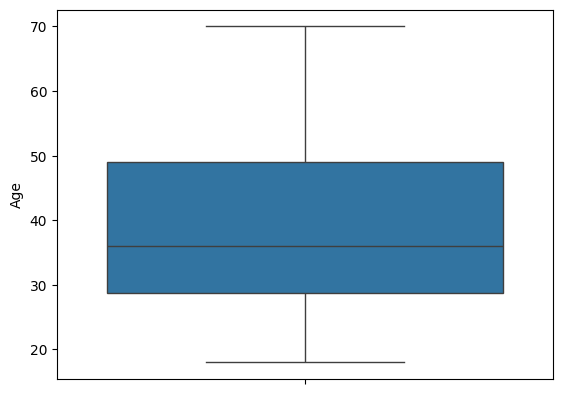

In [26]:
sns.boxplot(df['Age'])

<Axes: ylabel='Annual Income (k$)'>

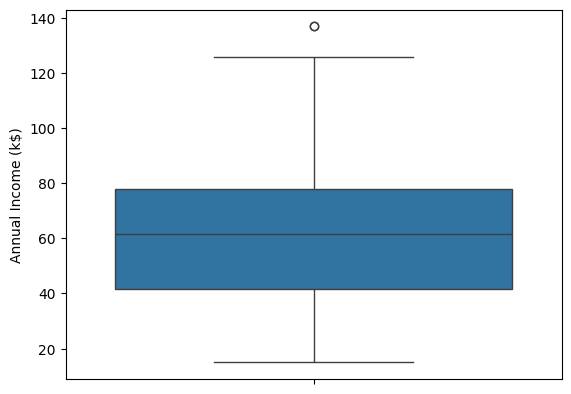

In [27]:
sns.boxplot(df['Annual Income (k$)'])

<Axes: ylabel='Spending Score (1-100)'>

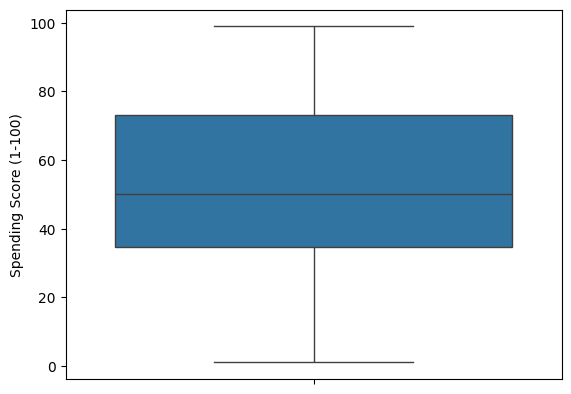

In [28]:
sns.boxplot(df['Spending Score (1-100)'])

B. Exploratory Data Analysis

Age Distribution

<Axes: xlabel='Age', ylabel='Count'>

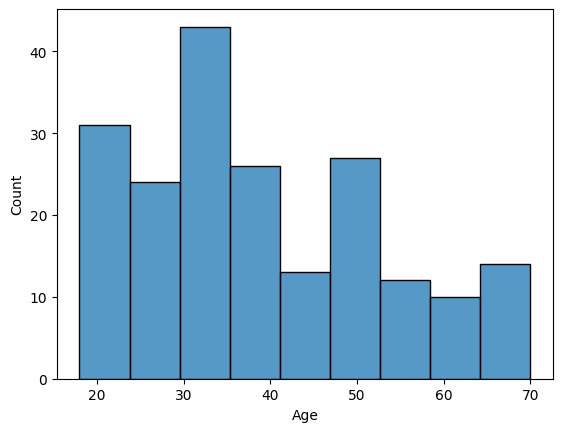

In [29]:
sns.histplot(df['Age'])

gender Distribution

<Axes: xlabel='Gender', ylabel='Count'>

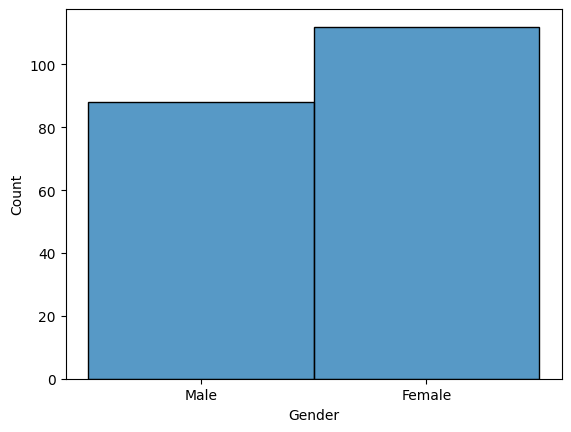

In [30]:
sns.histplot(df["Gender"])

Visualization 3 — Age vs Annual Income

<Axes: xlabel='Age', ylabel='Annual Income (k$)'>

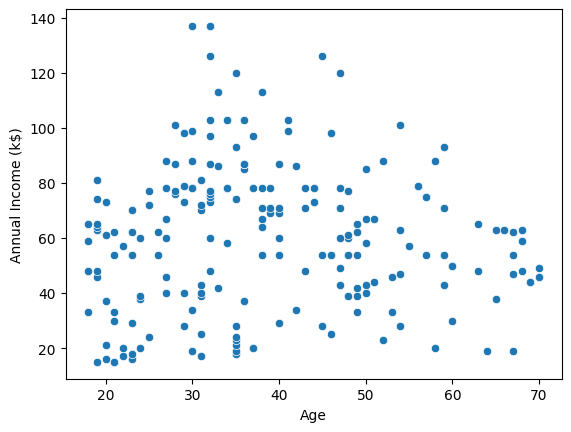

In [36]:
sns.scatterplot(
    x=df['Age'],
    y=df['Annual Income (k$)']
)

Correlation Heatmap

In [70]:
d = df[["Age","Annual Income (k$)","Spending Score (1-100)"]].corr()
d

,Age,Annual Income (k$),Spending Score (1-100)
Age,1.000000,-0.012398,-0.327227
Annual Income (k$),-0.012398,1.000000,0.009903
Spending Score (1-100),-0.327227,0.009903,1.000000


<Axes: >

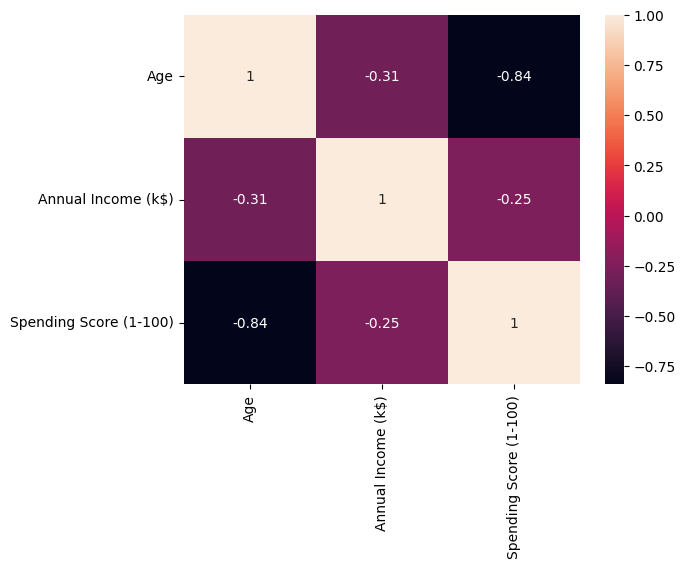

In [68]:
sns.heatmap(d.corr(),annot=True)

Spending Score by Gender

<Axes: xlabel='Gender', ylabel='Spending Score (1-100)'>

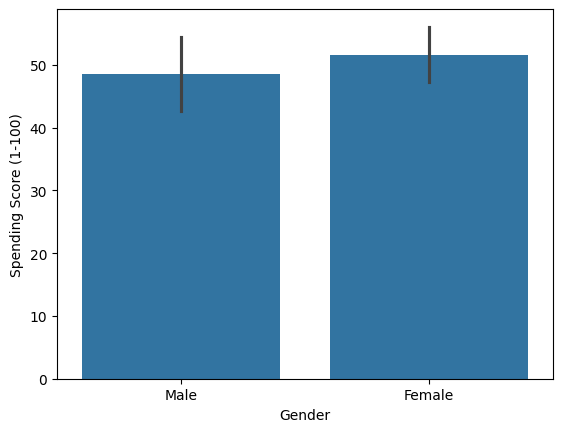

In [71]:
sns.barplot(
    x=df['Gender'],
    y=df['Spending Score (1-100)']
)

C. Feature Engineering

categorizing data into three segments

In [73]:
df["Age_group"]  = pd.cut(df["Age"],bins=3,labels=["Young","Middle","Old"])

In [74]:
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Age_group
0,1,Male,19,15,39,Young
1,2,Male,21,15,81,Young
2,3,Female,20,16,6,Young
3,4,Female,23,16,77,Young
4,5,Female,31,17,40,Young
...,...,...,...,...,...,...
195,196,Female,35,120,79,Young
196,197,Female,45,126,28,Middle
197,198,Male,32,126,74,Young
198,199,Male,32,137,18,Young


In [76]:
df["Age_group"].value_counts()

,count
Age_group,
Young,98
Middle,66
Old,36


In [50]:
df.groupby("Age_group")["Spending Score (1-100)"].mean()

/tmp/ipykernel_1316/4029030921.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Age_group")["Spending Score (1-100)"].mean()


,Spending Score (1-100)
Age_group,
Young,60.765306
Middle,41.227273
Old,37.888889


In [52]:
df.groupby(["Gender"])["Annual Income (k$)"].mean()

,Annual Income (k$)
Gender,
Female,59.250000
Male,62.227273


Income per Age

In [79]:
df["Income_per_Age"] = (
    df["Annual Income (k$)"] / df["Age"]
)

df[
    ["Age", "Annual Income (k$)", "Income_per_Age"]
].head()

,Age,Annual Income (k$),Income_per_Age
0,19,15,0.789474
1,21,15,0.714286
2,20,16,0.800000
3,23,16,0.695652
4,31,17,0.548387


Compare Spending by Age Group

<Axes: xlabel='Age_group', ylabel='Spending Score (1-100)'>

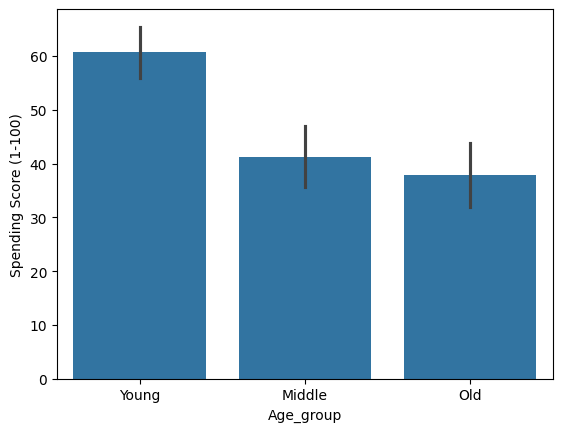

In [80]:
sns.barplot(
    x=df["Age_group"],
    y=df["Spending Score (1-100)"]
)

Five Key Insights

In [82]:
# ============================================================
# KEY INSIGHTS
# ============================================================

print("### Key Insights")

# Insight 1
print(
    "1. The customer dataset contains customers across "
    f"an age range of {df['Age'].min():.0f} to {df['Age'].max():.0f} years."
)

# Insight 2
print(
    "2. The average annual income is "
    f"{df['Annual Income (k$)'].mean():.2f} k$."
)

# Insight 3
print(
    "3. The average spending score is "
    f"{df['Spending Score (1-100)'].mean():.2f}."
)

# Insight 4
correlation = df.select_dtypes(include=np.number).corr()

spending_corr = (
    correlation["Spending Score (1-100)"]
    .drop("Spending Score (1-100)")
    .abs()
    .sort_values(ascending=False)
)

strongest_feature = spending_corr.index[0]

print(
    f"4. '{strongest_feature}' has the strongest numerical "
    "relationship with Spending Score among the available "
    "numeric features."
)

# Insight 5
largest_age_group = df["Age_group"].value_counts().idxmax()

print(
    f"5. The '{largest_age_group}' age group contains the "
    "largest number of customers."
)

### Key Insights
1. The customer dataset contains customers across an age range of 18 to 70 years.
2. The average annual income is 60.56 k$.
3. The average spending score is 50.20.
4. 'Age' has the strongest numerical relationship with Spending Score among the available numeric features.
5. The 'Young' age group contains the largest number of customers.
